In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


test_d = pd.read_csv('train.csv')
train_d = pd.read_csv('train.csv')
# print(test_d.columns)
# print(train_d.columns)

x = test_d.loc[:,"GrLivArea"].to_numpy()
y = train_d.loc[:,"SalePrice"].to_numpy()
# print(x, y)


In [2]:
# ===========================================================================
x_mean = x.mean()
y_mean = y.mean()

cov = np.mean((x - x_mean) * (y - y_mean))
var = np.mean((x - x_mean) ** 2)

beta1 = cov / var
beta0 = y_mean - beta1 * x_mean

y_hat = beta0 + beta1 * x
rss = np.sum((y - y_hat) ** 2)

print("beta0: ",beta0, "\nbeta1: ", beta1, "\nrss: ", rss)
# beta0:  18569.02585648725 
# beta1:  107.13035896582518 
# rss:  4584171086113.13

beta0:  18569.02585648725 
beta1:  107.13035896582518 
rss:  4584171086113.13


In [3]:
X = np.column_stack([np.ones(len(x)), x])

beta = np.linalg.pinv(X.T @ X) @ X.T @ y
y_hat = X @ beta
rss = np.sum((y - y_hat) ** 2)

print(beta, rss)
# [18569.02585643   107.13035897] 4584171086113.129

[18569.02585643   107.13035897] 4584171086113.129


In [4]:
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

print(model.intercept_, model.coef_[0])
# 18569.02585648722 107.1303589658252

18569.02585648722 107.1303589658252


In [5]:
import statsmodels.api as sm

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     1471.
Date:                Sat, 07 Feb 2026   Prob (F-statistic):          4.52e-223
Time:                        18:22:38   Log-Likelihood:                -18035.
No. Observations:                1460   AIC:                         3.607e+04
Df Residuals:                    1458   BIC:                         3.608e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.857e+04   4480.755      4.144      0.0

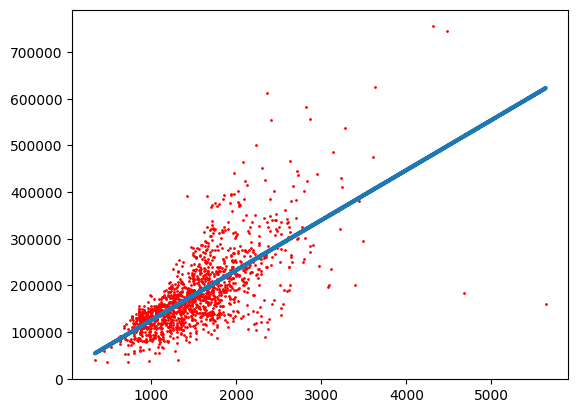

In [6]:
import matplotlib.pyplot as plt

plt.scatter(x, y, s=1, color="red")
plt.plot(x, y_hat, linewidth=3)
plt.show()